<a href="https://colab.research.google.com/github/seelasairani7730-wq/ai-video-tutor/blob/main/LoanPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importing required libraries
import pandas as pd


In [3]:
# check version on pandas
print('Version of pandas:', pd.__version__)

Version of pandas: 2.2.2


In [4]:
# reading the loan prediction data
data = pd.read_csv('loan_data.csv')

In [5]:
# looking at the first five rows of the data
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
# shape of the data
data.shape

(614, 13)

In [7]:
# checking missing values in the data
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [8]:
# data types of the variables
data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [13]:
# filling missing values of categorical variables with mode

# Numeric cols -> median, Categorical -> mode
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

In [14]:
# filling missing values of continuous variables with mean
data['LoanAmount'].fillna(data['LoanAmount'].mean())

,LoanAmount
0,128.0
1,128.0
2,66.0
3,120.0
4,141.0
...,...
609,71.0
610,40.0
611,253.0
612,187.0


In [15]:
# checking missing values after imputation
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [16]:
# converting the categories into numbers using map function
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
data['Married'] = data['Married'].map({'No': 0, 'Yes': 1})
data['Dependents'] = data['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Self_Employed'] = data['Self_Employed'].map({'No': 0, 'Yes': 1})
data['Property_Area'] = data['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})
data['Loan_Status'] = data['Loan_Status'].map({'N': 0, 'Y': 1})

In [17]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [18]:
# bringing variables in the range 0 to 1
data['Dependents']=(data['Dependents']-data['Dependents'].min())/(data['Dependents'].max()-data['Dependents'].min())

In [19]:
# applying for loop to bring all the variables in range 0 to 1

for i in data.columns[1:]:
    data[i] = (data[i] - data[i].min()) / (data[i].max() - data[i].min())

In [20]:
# again looking at first five rows of pre-processed data
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.172214,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


In [21]:
# saving the pre-processed data
data.to_csv('loan_prediction_data.csv', index=False)

In [22]:
#1.loading the dataset
#importing required libraries
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [23]:
print('version of sklearn:',sklearn.__version__)

version of sklearn: 1.6.1


In [24]:
data = pd.read_csv('loan_prediction_data.csv')

In [25]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.172214,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


In [26]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [27]:
data.dtypes

,0
Loan_ID,object
Gender,float64
Married,float64
Dependents,float64
Education,float64
Self_Employed,float64
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [28]:
data.shape

(614, 13)

In [29]:
data=data.drop('Loan_ID',axis=1)

In [30]:
data.shape

(614, 12)

In [31]:
#separating independent and dependent variables
#storing all the independent variables as X
X=data.drop('Loan_Status',axis=1)
#storing the dependent variables as y
Y=data['Loan_Status']

In [32]:
X.shape,Y.shape

((614, 11), (614,))

In [33]:
#2.creating training and validation set
#stratify will make sure that distribution of classes in train and validation set it similar
#random state to regenerate the same train and validation set
#test size 0.2 will keep 20% data in validation and remaining set in train set
X_train ,X_test,Y_train,Y_test = train_test_split(X,Y,stratify=data['Loan_Status'],random_state=10,test_size=0.2)

In [34]:
(X_train.shape,Y_train.shape),(X_test.shape,Y_test.shape)

(((491, 11), (491,)), ((123, 11), (123,)))

In [35]:
#3.defining the architecture of the model
import keras
print(keras.__version__)

3.13.2


In [36]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [37]:
from keras.models import Sequential

In [38]:
from keras.layers import InputLayer,Dense

In [39]:
X_train.shape

(491, 11)

In [40]:
X_train.shape[1]

11

In [41]:
input_neurons = X_train.shape[1]

In [42]:
output_neurons =1

In [43]:
number_of_hidden_layer=2
neuron_of_hidden_layer_1=10
neuron_of_hidden_layer_2=5

In [44]:
#activation function of different layers
#relu activation function for hidden layers,you can change it as well
#since it is binary classification ,i have used sigmoid activation function in the final layer


In [45]:
#defining the achitecture
model=Sequential()
model.add(InputLayer(input_shape=(input_neurons,)))
model.add(Dense(units=neuron_of_hidden_layer_1,activation='relu'))
model.add(Dense(units=neuron_of_hidden_layer_2,activation='relu'))
model.add(Dense(units=output_neurons ,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
input_neurons*neuron_of_hidden_layer_1

110

In [48]:
#number of parameters between input and first layer
#adding bias for each neuron of first hidden layer
input_neurons*neuron_of_hidden_layer_1+10

120

In [49]:
#number of parameters between first layer and second layer
#adding bias for each neuron of second hidden layer
neuron_of_hidden_layer_1*neuron_of_hidden_layer_2+5

55

In [50]:
#number of parameters between second hidden layer and output layer
neuron_of_hidden_layer_2*output_neurons+1

6

In [51]:
#compiling the model
#loss as binary _crossentropy,since we have binary classification problem
#defing the optimizer as adam
#evaluation metric as accuracy
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [52]:
#6.training the model
model_history = model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=50)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2912 - loss: 0.8824 - val_accuracy: 0.2764 - val_loss: 0.8220
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2505 - loss: 0.7799 - val_accuracy: 0.2683 - val_loss: 0.7491
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3544 - loss: 0.7261 - val_accuracy: 0.4634 - val_loss: 0.7121
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5438 - loss: 0.6945 - val_accuracy: 0.6423 - val_loss: 0.6863
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6456 - loss: 0.6718 - val_accuracy: 0.6504 - val_loss: 0.6660
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.6545 - val_accuracy: 0.6829 - val_loss: 0.6500
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6904 - loss: 0.6404 - val_accuracy: 0.6829 - val_loss: 0.6379
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6884 - loss: 0.6302 - val_accuracy: 0.6911 - val_loss

In [53]:
#6.Evaluting the model
#predictions
prediction = np.where(model.predict(X_test) < 0.5,0,1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [54]:
accuracy_score(Y_test,prediction)

0.8130081300813008

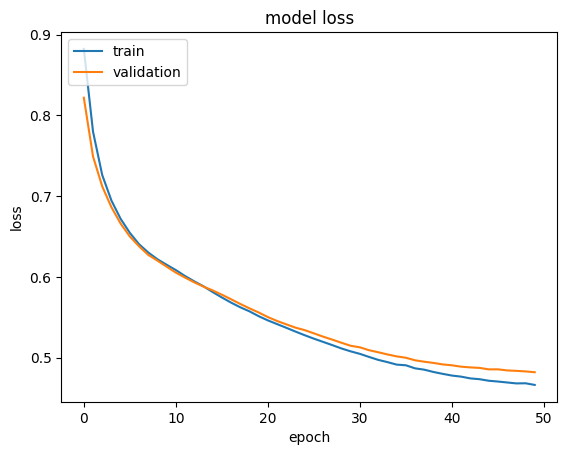

In [55]:
#7.visulazing the model performance
#summarize history for loss

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','validation'],loc='upper left')
plt.show()

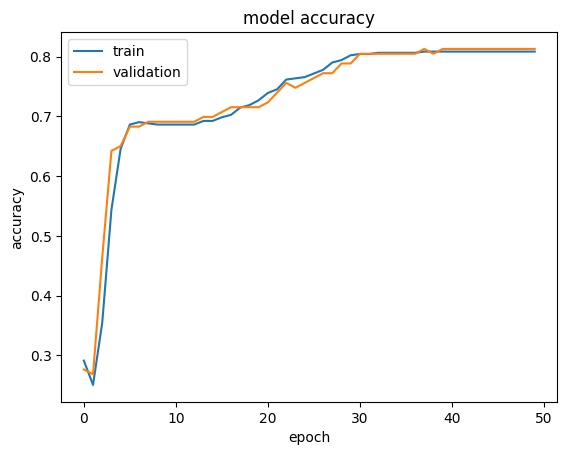

In [56]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','validation'],loc='upper left')